In [4]:
!pip -q install -U importlib_resources protobuf tensorflow-datasets tensorflow-metadata

In [6]:
import gc
import time
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE_SMALL = 160   # used for Tasks 1-5, 7 (many from-scratch training runs)
IMG_SIZE_FULL = 224    # used for Tasks 6, 8 (transfer learning + final model)
BATCH_SMALL = 16
BATCH_FULL = 32
NUM_CLASSES = 2  # Cat vs Dog

TRAIN_SUBSET = 1200   # images used per training run in Tasks 1-5, 7
VAL_SUBSET = 300       # images used per validation run in Tasks 1-5, 7

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    with_info=True,
    as_supervised=False,
)

def make_preprocess(img_size):
    def preprocess(example):
        image = tf.image.resize(example["image"], (img_size, img_size))
        image = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(image, tf.float32))
        return image, example["species"]  # species: 0 = Cat, 1 = Dog
    return preprocess

def make_pipeline(ds, img_size, shuffle=False, augment=False, batch_size=BATCH_SMALL):
    ds = ds.map(make_preprocess(img_size), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    if augment:
        aug = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.05)])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Light pipeline (160x160, batch 16, SUBSET of data) - Tasks 1-5, 7
train_ds_s = make_pipeline(ds_train.take(TRAIN_SUBSET), IMG_SIZE_SMALL, shuffle=True, augment=True, batch_size=BATCH_SMALL)
val_ds_s = make_pipeline(ds_val.take(VAL_SUBSET), IMG_SIZE_SMALL, batch_size=BATCH_SMALL)

# Full-resolution pipeline (224x224, batch 32) - Tasks 6, 8
train_ds_f = make_pipeline(ds_train, IMG_SIZE_FULL, shuffle=True, augment=True, batch_size=BATCH_FULL)
val_ds_f = make_pipeline(ds_val, IMG_SIZE_FULL, batch_size=BATCH_FULL)
test_ds_f = make_pipeline(ds_test, IMG_SIZE_FULL, batch_size=BATCH_FULL)

def build_model(initializer, img_size, dropout=0.0, l2_reg=0.0, use_bn=True, weights=None):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3), include_top=False, weights=weights, pooling="avg"
    )
    x = base.output
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax", kernel_initializer=initializer, kernel_regularizer=reg)(x)
    return base, models.Model(base.input, out)

def free_memory(*objs):
    """Delete given objects, clear the Keras backend graph, and force a GC pass.
    Call this after every model you finish training in a loop."""
    for o in objs:
        del o
    tf.keras.backend.clear_session()
    gc.collect()

print("Data pipelines ready:", ds_info.splits)
print(f"Tasks 1-5, 7 use a {TRAIN_SUBSET}-train/{VAL_SUBSET}-val subset at {IMG_SIZE_SMALL}x{IMG_SIZE_SMALL}")
print(f"Tasks 6, 8 use the full dataset at {IMG_SIZE_FULL}x{IMG_SIZE_FULL}")

Data pipelines ready: {'train': <SplitInfo num_examples=3680, num_shards=4>, 'test': <SplitInfo num_examples=3669, num_shards=4>}
Tasks 1-5, 7 use a 1200-train/300-val subset at 160x160
Tasks 6, 8 use the full dataset at 224x224


Task 6

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 638ms/step - accuracy: 0.9208 - loss: 0.2095 - val_accuracy: 0.9909 - val_loss: 0.0472
Epoch 2/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 36s 277ms/step - accuracy: 0.9852 - loss: 0.0602 - val_accuracy: 0.9964 - val_loss: 0.0303
Epoch 3/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 271ms/step - accuracy: 0.9880 - loss: 0.0424 - val_accuracy: 0.9946 - val_loss: 0.0238
Epoch 4/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 274ms/step - accuracy: 0.9903 - loss: 0.0372 - val_accuracy: 0.9982 - val_loss: 0.0212
Epoch 5/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.9911 - loss: 0.0293 - val_accuracy: 0.9909 - val_loss: 0.0260
Epoch 6/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9903 - loss: 0.0286 - val_accuracy: 0.9946 - val_loss: 0.0194
Epoch 7/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.9918 - loss: 0.0231 - val_accuracy: 0.9946 - val_loss: 0.0194
Epoch 8/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 40s 271ms/step - a

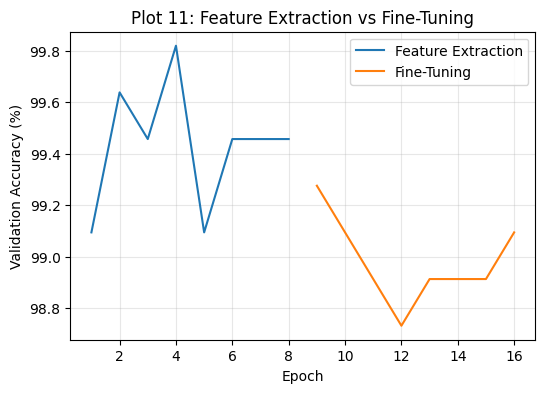

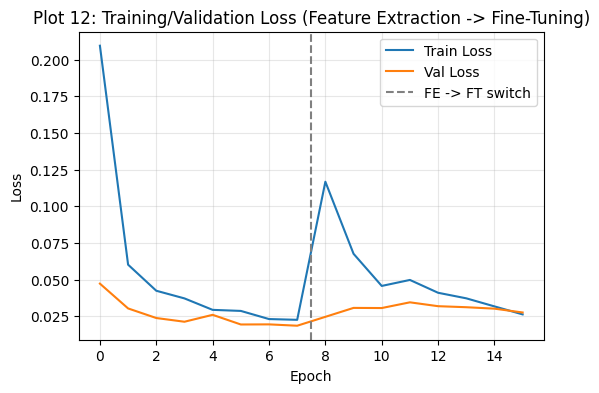

In [3]:
EPOCHS = 8

tf.keras.backend.clear_session()
base, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_FULL, dropout=0.3, use_bn=False, weights="imagenet")

base.trainable = False
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_fe = model.fit(train_ds_f, validation_data=val_ds_f, epochs=EPOCHS, verbose=1).history

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_ft = model.fit(train_ds_f, validation_data=val_ds_f, epochs=EPOCHS, verbose=1).history

plt.figure(figsize=(6, 4))
fe_acc = [a * 100 for a in hist_fe["val_accuracy"]]
ft_acc = [a * 100 for a in hist_ft["val_accuracy"]]
plt.plot(range(1, len(fe_acc) + 1), fe_acc, label="Feature Extraction")
plt.plot(range(len(fe_acc) + 1, len(fe_acc) + len(ft_acc) + 1), ft_acc, label="Fine-Tuning")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs Fine-Tuning")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

plt.figure(figsize=(6, 4))
plt.plot(hist_fe["loss"] + hist_ft["loss"], label="Train Loss")
plt.plot(hist_fe["val_loss"] + hist_ft["val_loss"], label="Val Loss")
plt.axvline(x=len(hist_fe["loss"]) - 0.5, color="gray", linestyle="--", label="FE -> FT switch")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 12: Training/Validation Loss (Feature Extraction -> Fine-Tuning)")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

free_memory(model, base)